In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json 


In [2]:
data = pd.read_csv("data/company_tickers.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10412 entries, 0 to 10411
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cik_str         10412 non-null  int64  
 1   ticker          10411 non-null  str    
 2   title           10412 non-null  str    
 3   sicDescription  9082 non-null   str    
 4   exchanges       10412 non-null  str    
 5   entityType      10412 non-null  str    
 6   ownerOrg        9299 non-null   str    
 7   sic             9096 non-null   float64
 8   category        8444 non-null   str    
 9   fiscalYearEnd   9845 non-null   float64
 10  addresses       10412 non-null  str    
 11  phone           10377 non-null  str    
dtypes: float64(2), int64(1), str(9)
memory usage: 976.3 KB


In [7]:
data.apply(lambda col: col.duplicated().sum())

cik_str            2344
ticker                0
title              2344
sicDescription    10009
exchanges         10331
entityType        10409
ownerOrg          10400
sic               10008
category          10397
fiscalYearEnd     10327
addresses          2967
phone              3057
dtype: int64

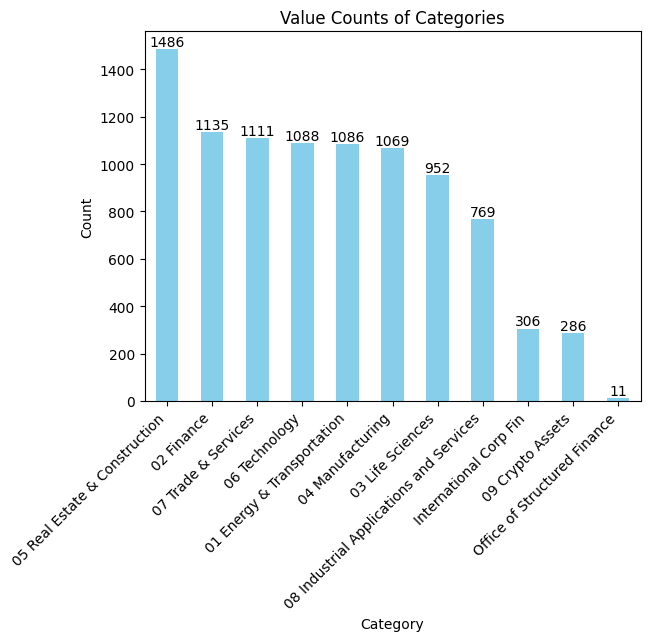

In [3]:
segmentation = data.ownerOrg.value_counts()
ax =segmentation.plot(kind="bar", color="skyblue", rot=0)
plt.title("Value Counts of Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container)

plt.show()

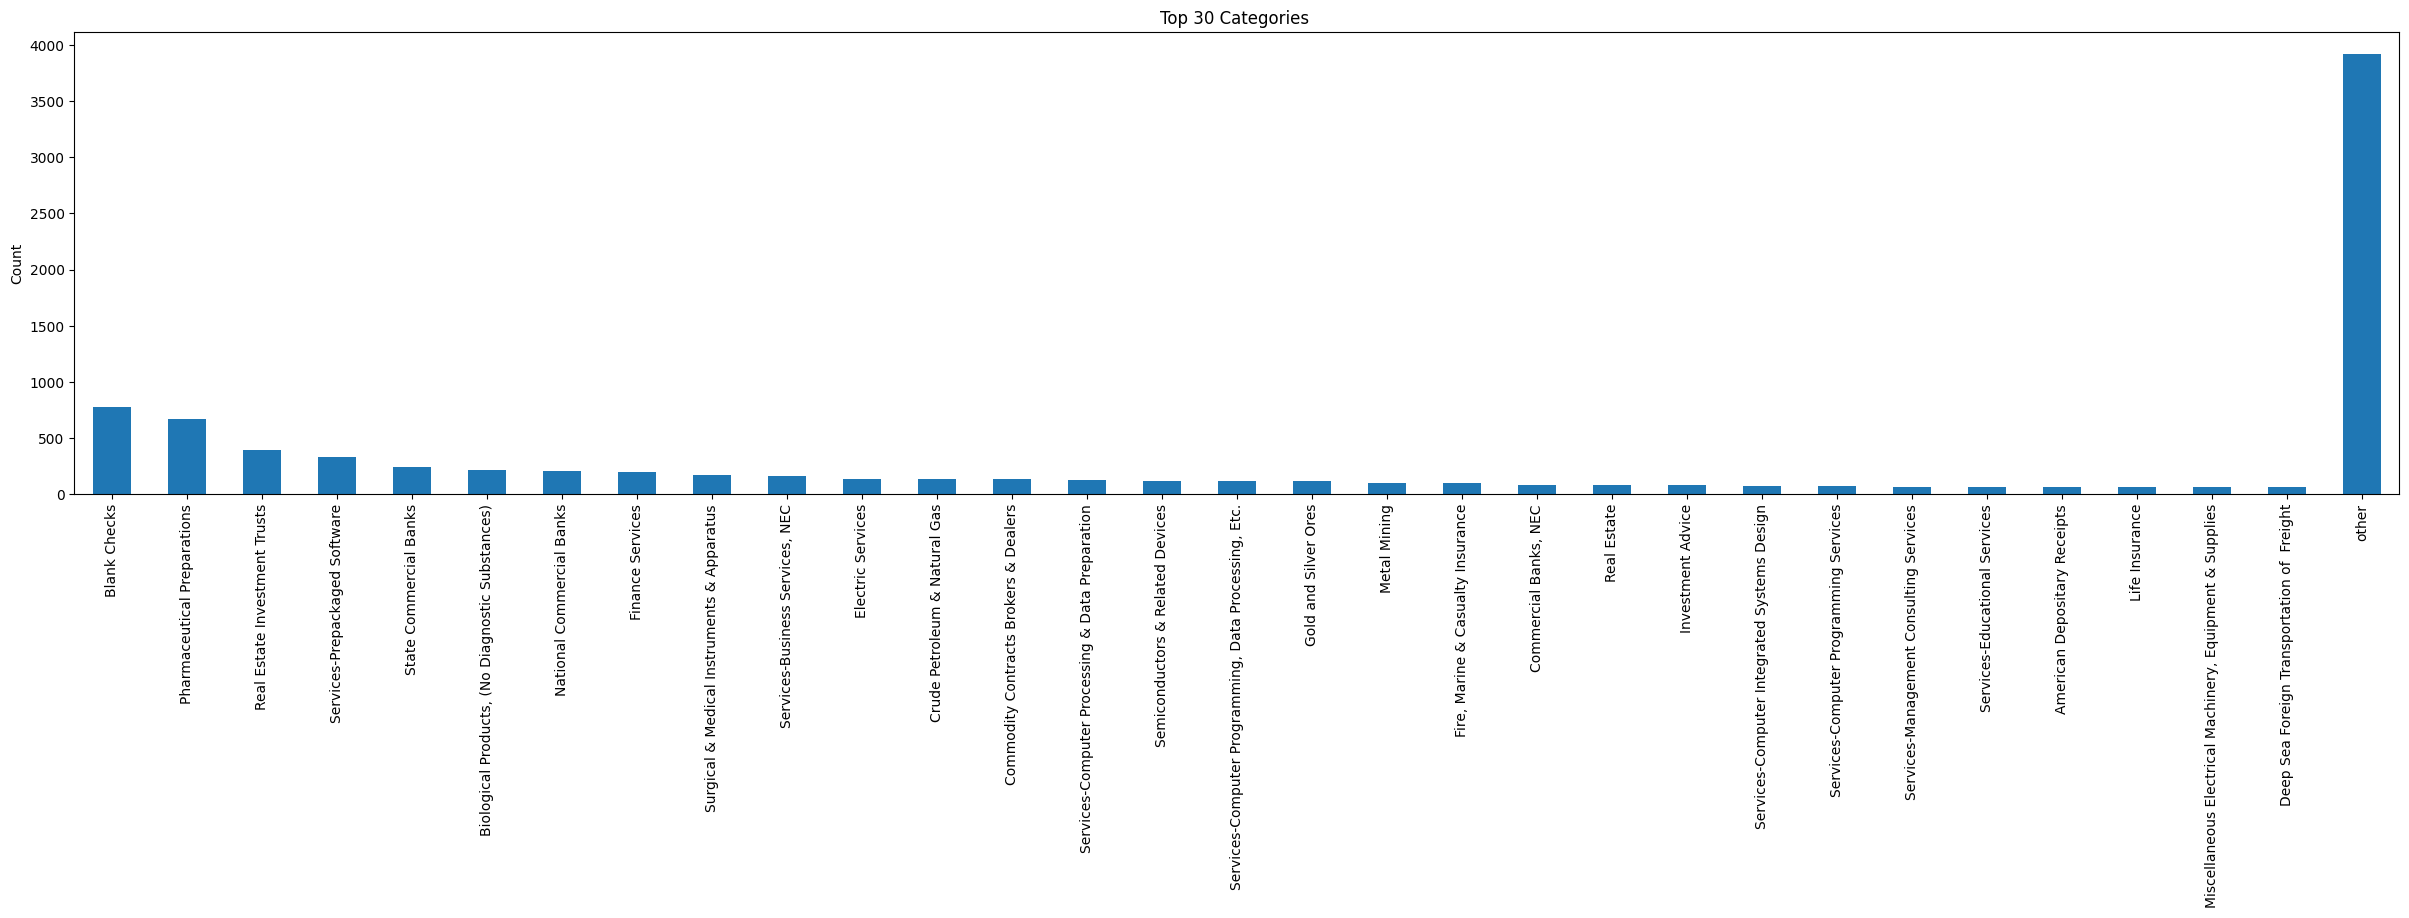

In [4]:
subcategory = data.sicDescription.value_counts()
top_30 = subcategory[:30]
other_count = subcategory[30:].sum()
others_series = pd.Series({"other": other_count})
final_counts = pd.concat([top_30, others_series])
final_counts.plot(kind='bar', figsize=(30, 6))
plt.title('Top 30 Categories ')
plt.ylabel('Count')
plt.show()

In [5]:
first = str(data["cik_str"].iloc[0]).zfill(10)

companyfacts = pd.read_json(f"data/companyfacts/CIK{first}.json").to_dict()

def get_structure(obj):
    if isinstance(obj, dict):
        return {k: get_structure(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [get_structure(obj[0])] if obj else []
    return type(obj).__name__

facts = companyfacts.get("facts", {})
dei = facts.get("dei", {})
invest = facts.get("invest", {})
us_gaap = facts.get("us-gaap", {})
srt = facts.get("srt", {})

schema = get_structure(companyfacts)
print(json.dumps(schema, indent=4)) 

with open('company_fact_schema' , 'w') as file : 
    json.dump( schema , file , indent= 4 )

{
    "cik": {
        "dei": "int",
        "invest": "int",
        "us-gaap": "int",
        "srt": "int"
    },
    "entityName": {
        "dei": "str",
        "invest": "str",
        "us-gaap": "str",
        "srt": "str"
    },
    "facts": {
        "dei": {
            "EntityCommonStockSharesOutstanding": {
                "label": "str",
                "description": "str",
                "units": {
                    "shares": [
                        {
                            "end": "str",
                            "val": "int",
                            "accn": "str",
                            "fy": "int",
                            "fp": "str",
                            "form": "str",
                            "filed": "str",
                            "frame": "str"
                        }
                    ]
                }
            },
            "EntityPublicFloat": {
                "label": "str",
                "description": "str",